# CIFAR-10 kuvien luokittelu CNN-mallilla

Tässä työssä toteutetaan konvoluutioneuroverkko, jolla luokitellaan CIFAR-10-datasetin kuvia. Tavoitteena on opettaa malli tunnistamaan 10 eri luokkaa värikuvista ja arvioida sen suorituskykyä.

## Importit

Tässä tuodaan tarvittavat kirjastot neuroverkon rakentamiseen, datan käsittelyyn ja tulosten visualisointiin.

In [11]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

## Datan lataus

Ladataan CIFAR-10 dataset, joka sisältää 50 000 koulutuskuvaa ja 10 000 testikuvaa. Jokainen kuva on kooltaan 32x32 ja sisältää 3 värikanavaa (RGB).

In [12]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Datan esikäsittely

Normalisoidaan kuvien pikseliarvot välille [0,1], jotta mallin oppiminen on tehokkaampaa. Lisäksi muunnetaan luokat one-hot -muotoon, jotta ne sopivat neuroverkon ulostuloon.

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## CNN-mallin määrittely

Rakennetaan konvoluutioneuroverkko, joka koostuu konvoluutiokerroksista, pooling-kerroksista ja täysin yhdistetyistä kerroksista. Malli oppii tunnistamaan kuvista piirteitä ja luokittelemaan ne oikeaan luokkaan.

In [4]:
inputs = keras.Input(shape=(32, 32, 3))

x = layers.Conv2D(32, (3,3), activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation="relu")(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(128, (3,3), activation="relu")(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,938 (1.36 MB)

 Trainable params: 356,874 (1.36 MB)

 Non-trainable params: 64 (256.00 B)

## Mallin kääntäminen

Määritellään optimointimenetelmä ja häviöfunktio.

In [14]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Mallin koulutus

Koulutetaan malli ja seurataan sen oppimista validointidatan avulla.

In [6]:
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.4239 - loss: 1.5802 - val_accuracy: 0.4934 - val_loss: 1.4099
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.5756 - loss: 1.2184 - val_accuracy: 0.6025 - val_loss: 1.1241
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.6351 - loss: 1.0505 - val_accuracy: 0.6272 - val_loss: 1.0639
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.6731 - loss: 0.9397 - val_accuracy: 0.6713 - val_loss: 0.9637
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.7071 - loss: 0.8530 - val_accuracy: 0.6814 - val_loss: 0.9263
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.7302 - loss: 0.7741 - val_accuracy: 0.6697 - val_loss: 0.9716
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.7510 - loss: 0.7219 - val_accuracy: 0.6354 - val_loss: 1.1213
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.7698 - loss: 0.6611 - 

## Mallin evaluointi

Testataan mallin tarkkuus testidatalla.

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7149 - loss: 1.0289
Test accuracy: 0.714900016784668


## Oppimiskäyrät

Visualisoidaan training ja validation loss.

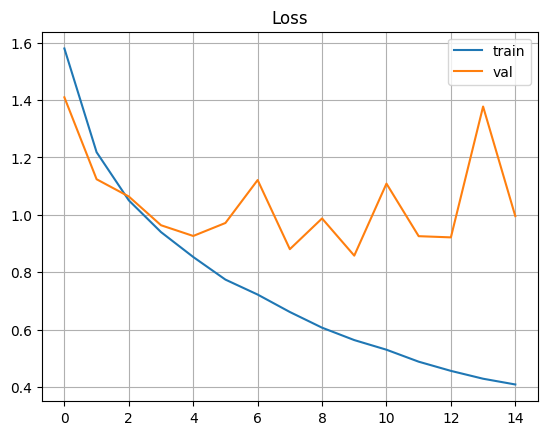

In [8]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")
plt.grid()
plt.show()

## Ennusteiden visualisointi

Näytetään mallin ennusteita testikuville.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


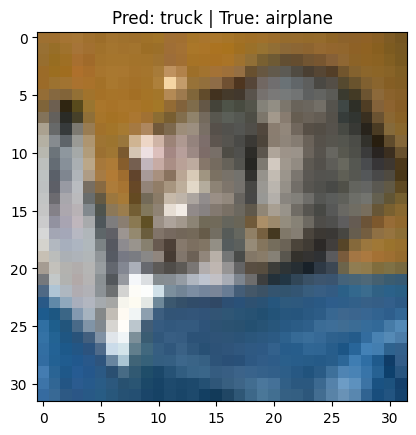

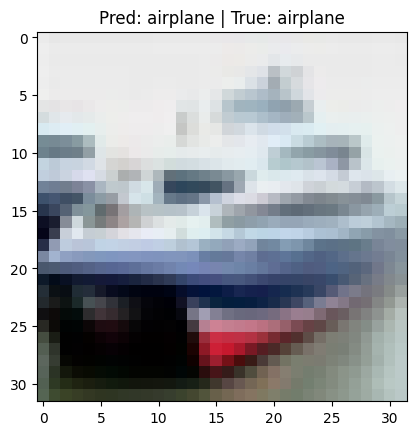

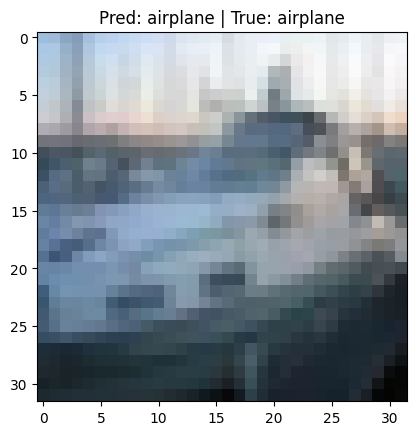

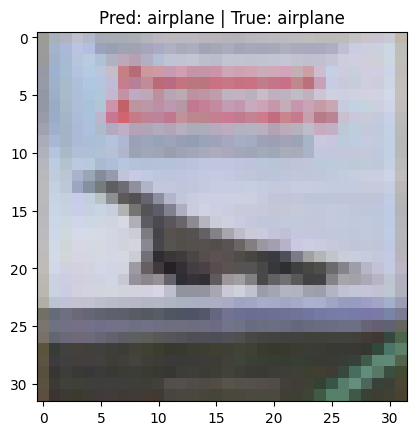

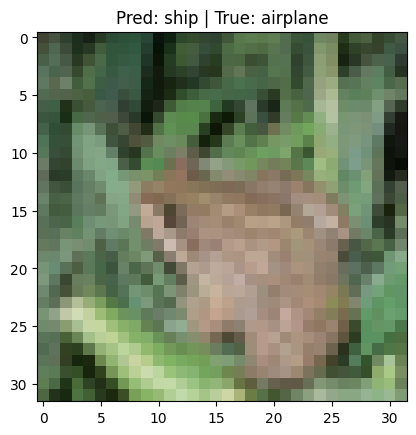

In [15]:
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

predictions = model.predict(x_test)

for i in range(5):
    plt.imshow(x_test[i])
    pred = np.argmax(predictions[i])
    true = np.argmax(y_test[i])
    plt.title(f"Pred: {class_names[pred]} | True: {class_names[true]}")
    plt.axis("on")
    plt.show()

## Väärin luokitellut kuvat

Tarkastellaan mallin tekemiä virheitä.

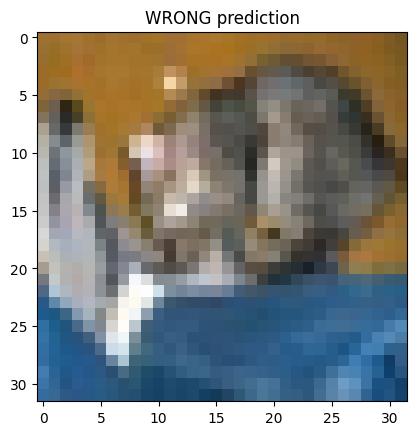

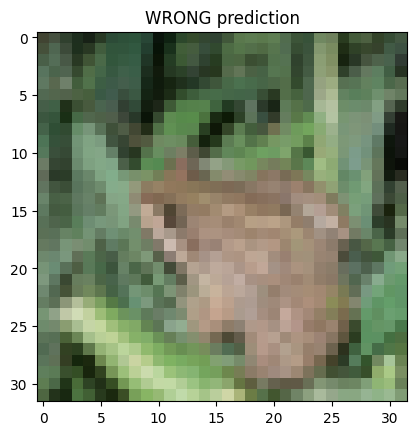

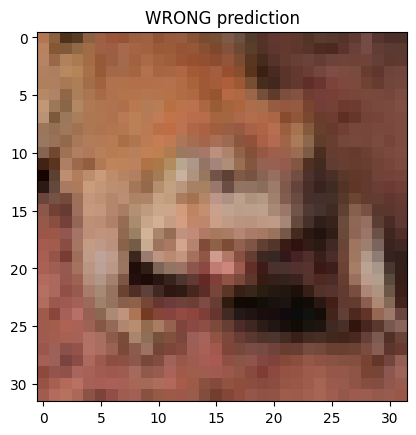

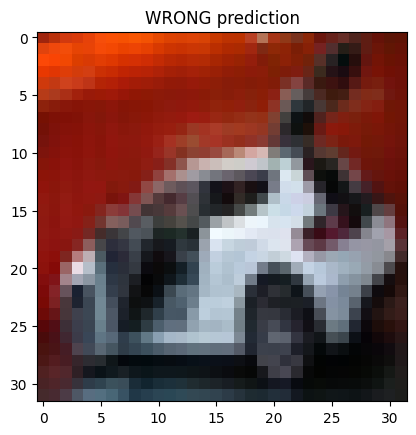

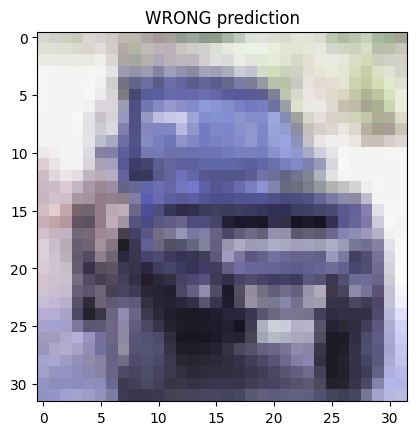

In [16]:
wrong = np.where(
    np.argmax(predictions, axis=1) != np.argmax(y_test, axis=1)
)[0]

for i in wrong[:5]:
    plt.imshow(x_test[i])
    plt.title("WRONG prediction")
    plt.axis("on")
    plt.show()